### 🤖 Implement ReAct with LangGraph-What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [47]:
import os
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END
from langgraph.graph import StateGraph
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph.message import add_messages

In [48]:
# --------------------------
# 1. Create Retriever Tool
# --------------------------

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

embedding = (OllamaEmbeddings(model="nomic-embed-text"))
vectorstore = FAISS.from_documents(chunks, embedding)
retriever = vectorstore.as_retriever()

In [49]:
retriever.invoke("what are autonomous agents")

[Document(id='26814c3b-0bdc-4264-8f6d-de3e2bbd22fd', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [57]:
@tool
def retriever_tool(query: str) -> str:
    """Use this tool to fetch relevant knowledge base info"""
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [58]:
import wikipediaapi
from langchain.tools import tool

wiki = wikipediaapi.Wikipedia(
    language="en",
    user_agent="ultimate-rag-bootcamp/1.0 (harshit@example.com)"
)

@tool
def wikipedia(query: str) -> str:
    """Search Wikipedia."""
    page = wiki.page(query)

    if not page.exists():
        return "Wikipedia page not found."

    return page.summary

In [59]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

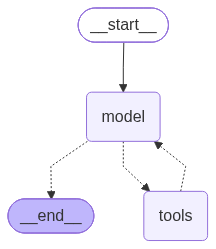

In [60]:
# ----------------------------
# 2. Define the Agent Node
# ----------------------------

tools = [retriever_tool, wikipedia]

## create the native Langgraph react agent
llm = llm.bind_tools(tools)

react_node = create_agent(
    model=llm,
    tools=tools,
)

react_node

In [64]:
# --------------------------
# 3. LangGraph Agent State
# --------------------------

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

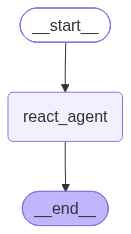

In [65]:
# --------------------------
# 4. Build LangGraph Graph
# --------------------------

builder = StateGraph(AgentState)

builder.add_node("react_agent", react_node)
builder.set_entry_point("react_agent")
builder.add_edge("react_agent", END)

graph = builder.compile()
graph

In [66]:
# --------------------------
# 5. Run the ReAct Agent
# --------------------------

user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
state = {"messages": [HumanMessage(content=user_query)]}
result = graph.invoke(state)

print("\n✅ Final Answer:\n", result["messages"][-1].content)

📚 Using RAGRetriever tool
📚 Using RAGRetriever tool

✅ Final Answer:
 **1. The “agent loop” – what it is and why it matters**

In the world of LLM‑powered (or more generally AI‑powered) autonomous agents, the *agent loop* is the recurring cycle that lets the system interact with its environment, reason about what to do next, and improve over time.  
A typical loop looks like this:

| Step | What happens | Typical LLM‑agent implementation |
|------|--------------|-----------------------------------|
| **1. Observe / Perceive** | The agent gathers information from the world (e.g., reads a web page, receives a user message, inspects the output of a tool). | The LLM receives a *prompt* that contains the latest observations, a short “scratch‑pad” of prior thoughts, and any retrieved data. |
| **2. Think / Plan** | Using the new observations, the agent decides what goal‑oriented action to take next. This may involve decomposing a high‑level task into sub‑tasks, selecting a tool, or generatin

### Tool creation for RAG agents with langgraph 
To create tools for RAG agents using LangGraph, you're essentially building LLM-invocable functions that your agent can call as part of its reasoning + acting loop (ReAct).

LangGraph uses the Tool abstraction from LangChain and fully supports tools for:

- RAG retrieval
- Search
- Wikipedia
- SQL
- Web APIs
- Calculators, etc.

#### ✅ Tool Design Requirements
A LangGraph tool must:

- Have a name
- Have a description (used by the LLM to decide when to use it)
- Have a callable func, accepting a single input (usually str) and returning str

In [67]:
import wikipediaapi

from typing import Annotated, Sequence, TypedDict

from langchain.agents import create_agent
from langchain.tools import tool

from langchain_core.messages import BaseMessage, HumanMessage

from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS

from langchain_community.document_loaders import (
    TextLoader,
    ArxivLoader,
)

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

In [68]:
llm

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CFA890E950>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CFA890E550>, model_name='openai/gpt-oss-120b', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'retriever_t

In [69]:
### Generic function to create a retireval tool
def make_retriever_tool_from_text(file, name, description):

    docs = TextLoader(
        file,
        encoding="utf-8"
    ).load()

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=50,
    )

    chunks = splitter.split_documents(docs)

    vectorstore = FAISS.from_documents(
        chunks,
        OllamaEmbeddings(model="nomic-embed-text")
    )

    retriever = vectorstore.as_retriever()

    @tool(name)
    def retriever_tool(query: str) -> str:
        """Retrieve relevant information from internal documents."""

        print(f"📚 Using {name}")

        docs = retriever.invoke(query)

        return "\n\n".join(doc.page_content for doc in docs)

    retriever_tool.description = description

    return retriever_tool

In [70]:
wiki = wikipediaapi.Wikipedia(
    language="en",
    user_agent="ultimate-rag-agent/1.0"
)


@tool
def wikipedia(query: str) -> str:
    """Search Wikipedia."""

    print("🌍 Searching Wikipedia...")

    page = wiki.page(query)

    if not page.exists():
        return "Wikipedia page not found."

    return page.summary[:4000]

In [90]:
# @tool
# def arxiv_search(query: str) -> str:
#     """Search recent research papers from ArXiv."""

#     print("🧪 Searching ArXiv...")

#     docs = ArxivLoader(query=query).load()

#     if not docs:
#         return "No papers found."

#     return "\n\n".join(
#         doc.page_content[:1000]
#         for doc in docs[:2]
#     )

import arxiv

@tool
def arxiv_search(query: str) -> str:
    """Search recent ArXiv papers."""

    client = arxiv.Client()

    search = arxiv.Search(
        query=query,
        max_results=2
    )

    papers = client.results(search)

    return "\n\n".join(
        f"Title: {p.title}\n\n{p.summary[:1000]}"
        for p in papers
    )

In [91]:
internal_tool_1=make_retriever_tool_from_text(
    "sample_docs.txt",
    "SampleTechDocs",
    "Search Sample tech documents for proprietary architecture and methods."
)
internal_tool_1

StructuredTool(name='SampleTechDocs', description='Search Sample tech documents for proprietary architecture and methods.', args_schema=<class 'langchain_core.utils.pydantic.SampleTechDocs'>, func=<function make_retriever_tool_from_text.<locals>.retriever_tool at 0x000001CFAB7D4040>)

In [92]:
internal_tool_2 = make_retriever_tool_from_text(
    "research_notes.txt",
    "InternalResearchNotes",
    "Search internal research notes for experimental results and agent designs."
)
internal_tool_2

StructuredTool(name='InternalResearchNotes', description='Search internal research notes for experimental results and agent designs.', args_schema=<class 'langchain_core.utils.pydantic.InternalResearchNotes'>, func=<function make_retriever_tool_from_text.<locals>.retriever_tool at 0x000001CFAB7D7420>)

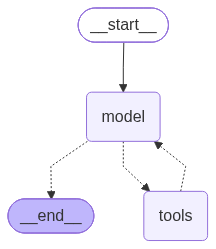

In [93]:
tools=[wikipedia,arxiv_search,internal_tool_1,internal_tool_2]

react_node = create_agent(
    model=llm,
    tools=tools,
)

react_node

In [94]:
class AgentState(TypedDict):
    messages: Annotated[
        Sequence[BaseMessage],
        add_messages,
    ]

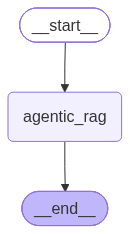

In [95]:
builder = StateGraph(AgentState)
builder.add_node("agentic_rag", react_node)
builder.set_entry_point("agentic_rag")
builder.add_edge("agentic_rag", END)

graph = builder.compile()
graph

In [96]:
query = (
    "What do our internal research notes say "
    "about transformer variants, and what does "
    "ArXiv suggest recently?"
)

state = {
    "messages": [
        HumanMessage(content=query)
    ]
}

result = graph.invoke(state)

print(result["messages"][-1].content)

📚 Using InternalResearchNotes
🌍 Searching Wikipedia...
**1. What our internal research notes say about transformer variants (July 2024)**  

| Variant | What we tried | Key quantitative findings | Practical take‑aways |
|---------|---------------|---------------------------|----------------------|
| **EfficientFormer** (vision‑focused) | Deployed on a Raspberry Pi 4, quantised to int‑8. | • Top‑1 = 92.4 % on TinyImageNet  <br>• Peak RAM ≈ 290 MiB (batch‑size 16) | • Works “out‑of‑the‑box” on edge devices; int‑8 quantisation incurs < 1 % accuracy loss. <br>• Good baseline when you need a lightweight visual encoder for multimodal pipelines. |
| **Longformer** (sparse‑window + global attention) | Ran on customer‑support logs (max 8192 tokens) in a streaming‑chat setting. | • Latency ≈ 1.2 s per query (still high for real‑time). <br>• Chunk‑based hybrid attention reduces latency modestly vs. full‑self‑attention. | • Viable for “medium‑length” documents (few‑thousand tokens) when you can to